# **LightGBM (tweedie)**

D8 solutions

As a baseline, the current collision-parts forecast (using the generic model) has a WMAPE of around 70% using a 2-month lag and a 3-month rolling average. 

Forecast requirements: 
- **Granularity:** Provide monthly forecasts at the SKU level, for the defined collision parts scope.
- **Horizon**: Forecast 18 months ahead, updated monthly.
- **Accuracy metric:** Use WMAPE, assessed with: 
    - 3-month forecast lag (forecasts are judged against actuals two months later)
    - 3-month rolling average of WMAPE (to smooth month-to-month noise)
- **Benchmarking:** Compare results against the current baseline model, with improvement reported in WMAPE points and %.
- **Backtesting:** Use a rolling-origin backtest that matches the real operating cadence (train on history, predict forward with the 3-month lag).
- **Edge cases:** Be explicit about how you handle:
    - Zero-demand months (common in collision parts)
    - New / discontinued / superseded SKUs
- **Outputs:** Provide forecasts plus a short explanation of what drives performance (where it works well, where it struggles, and why) and provide the meaning of the features used.

**Load libraries**

In [11]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\David\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown
import os
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


**Load data**

In [3]:
# define where to write data
output_dir = r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project'

# retrieve only sales_collision.csv from the drive folder
gdown.download(
    id='1zG72xZfvKuNxS3qZUwb2q8GIW3dn_oW4',
    output=os.path.join(output_dir, 'sales_collision.csv'),
    quiet=False
)

# sales_collision
sales_collision = pd.read_csv(os.path.join(output_dir, 'sales_collision.csv'))


Downloading...
From: https://drive.google.com/uc?id=1zG72xZfvKuNxS3qZUwb2q8GIW3dn_oW4
To: C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\sales_collision.csv
100%|██████████| 56.8M/56.8M [00:02<00:00, 21.2MB/s]


**Basic checks to assess if data is correctly loaded**

There should be the following number of rows: 180422

Unique SKUs: 8097

Number by demand_type (Total demand)

- Smooth ... 972 (156317)
- Intermittent ... 6593 (52809)
- Lumpy ... 381 (12349)
- Erratic ... 124 (16049)

In [4]:
# check shape
print(f"There are {sales_collision.shape[0]} rows and {sales_collision.shape[1]} features")

There are 180422 rows and 48 features


In [5]:
# unique SKUs
print(sales_collision['sku_id'].nunique())

8097


In [6]:
# print demand types
print(sales_collision['demand_type'].unique())

['Intermittent' 'Lumpy' 'Smooth' 'Erratic' 'No demand observed']


In [7]:
# get table of demand_type
print(sales_collision.groupby('sku_id')['demand_type'].first().value_counts())

demand_type
Intermittent          6593
Smooth                 972
Lumpy                  381
Erratic                124
No demand observed      27
Name: count, dtype: int64


In [8]:
print(sales_collision.groupby('demand_type')['demand'].sum())

demand_type
Erratic                16049.0
Intermittent           52809.0
Lumpy                  12349.0
No demand observed         0.0
Smooth                156317.0
Name: demand, dtype: float64


In [9]:
# add total demand by sku_id as additional column
total_demand_by_sku = sales_collision.groupby('sku_id')['demand'].sum().rename('total_demand_sku')
sales_collision = sales_collision.merge(total_demand_by_sku, on='sku_id', how='left')

# mark top 20% SKUs by total demand
threshold = sales_collision['total_demand_sku'].quantile(0.80)
sales_collision['is_top20pct'] = (sales_collision['total_demand_sku'] >= threshold).astype(int)

# mark top 5% SKUs by total demand
threshold = sales_collision['total_demand_sku'].quantile(0.95)
sales_collision['is_top5pct'] = (sales_collision['total_demand_sku'] >= threshold).astype(int)

**LightGBM (tweedie)**

In [13]:
# Set up and feature engineering

FORECAST_LAG = 3    # months between forecast origin and target
N_FORECAST   = 18   # months ahead to forecast
MIN_TRAIN    = 100  # minimum training rows per backtest fold

# ── Base dataframe ─────────────────────────────────────────────────────────────
df = sales_collision[['sku_id', 'month', 'demand', 'demand_type']].copy()
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['sku_id', 'month']).reset_index(drop=True)

# ── Feature engineering ────────────────────────────────────────────────────────
def engineer_features(data):
    data = data.sort_values(['sku_id', 'month']).copy()
    g = data.groupby('sku_id')['demand']

    for l in [3, 4, 5, 6, 9, 12, 15]:
        data[f'lag_{l}m'] = g.shift(l)

    for w in [3, 6, 12]:
        data[f'roll_mean_{w}m'] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).mean())
        data[f'roll_std_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).std().fillna(0))
        data[f'roll_max_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).max())

    data['_iz'] = (data['demand'] == 0).astype(float)
    gz = data.groupby('sku_id')['_iz']
    data['zero_share_6m']  = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(6,  min_periods=1).mean())
    data['zero_share_12m'] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(12, min_periods=1).mean())
    data.drop(columns=['_iz'], inplace=True)

    data['month_of_year'] = data['month'].dt.month
    data['quarter']       = data['month'].dt.quarter
    data['year']          = data['month'].dt.year

    first_sale = (
        data[data['demand'] > 0].groupby('sku_id')['month'].min().rename('_first_sale')
    )
    data = data.merge(first_sale, on='sku_id', how='left')
    data['sku_age_months'] = (
        (data['month'].dt.year  - data['_first_sale'].dt.year)  * 12
        + (data['month'].dt.month - data['_first_sale'].dt.month)
    ).clip(lower=0).fillna(0)
    data['is_new_sku']     = (data['sku_age_months'] < 6).astype(int)
    data.drop(columns=['_first_sale'], inplace=True)

    return data

FEATURE_COLS = (
    [f'lag_{l}m'         for l in [3, 4, 5, 6, 9, 12, 15]]
    + [f'roll_mean_{w}m' for w in [3, 6, 12]]
    + [f'roll_std_{w}m'  for w in [3, 6, 12]]
    + [f'roll_max_{w}m'  for w in [3, 6, 12]]
    + ['zero_share_6m', 'zero_share_12m',
       'month_of_year', 'quarter', 'year', 'sku_age_months', 'is_new_sku']
)

df = engineer_features(df)
print(f"Dataset: {df.shape[0]:,} rows | {len(FEATURE_COLS)} features")
print("NaN share (top 5):")
print(df[FEATURE_COLS].isnull().mean().sort_values(ascending=False).head())


Dataset: 180,422 rows | 23 features
NaN share (top 5):
lag_15m    0.630422
lag_12m    0.514699
lag_9m     0.392801
lag_6m     0.265372
lag_5m     0.221813
dtype: float64


<u>Interpretation</u>

*23 features* — the engineered feature columns defined in FEATURE_COLS (lags, rolling stats, zero share, calendar, SKU age).

*NaN share* — the fraction of rows where that feature is missing:
- lag_15m = 0.63 → 63% of rows have no value for demand 15 months ago
- lag_12m = 0.51 → 51% missing for 12 months ago
- etc.

*Why so many NaNs?* Two reasons:
1. Short history: if a SKU only entered the data 6 months ago, it has no demand value from 12 or 15 months ago — those lags simply don't exist yet.
2. Lag anchoring: lags start at lag_3m (not lag_1m), so even SKUs with a full history lose the first 3 rows.

*Is this a problem?* No — XGBoost handles NaNs natively by learning which branch direction is best for missing values. The dropna(subset=feature_cols) in the backtest only drops rows where all features are missing, which would be SKUs with fewer than 3 months of history (essentially brand new SKUs with no usable signal at all).


In [14]:
# WMAPE + Baseline
# ── WMAPE ──────────────────────────────────────────────────────────────────────
# Weighted by actual demand so large-volume SKUs count more.
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = y_true.sum()
    return np.nan if denom == 0 else np.abs(y_true - y_pred).sum() / denom

# ── Baseline: 3-month rolling average of lag-3 demand ─────────────────────────
# Mirrors the real operating cadence: at forecast origin T, use the average of
# the three most recent known months (T, T-1, T-2) to predict T+3.
def baseline_wmape(data):
    d = data.sort_values(['sku_id', 'month']).copy()
    d['_bl'] = d.groupby('sku_id')['demand'].transform(
        lambda x: x.shift(FORECAST_LAG).rolling(3, min_periods=1).mean()
    )
    valid = d.dropna(subset=['_bl'])
    return wmape(valid['demand'].values, valid['_bl'].values)


In [15]:
# Rolling-origin Backtest + Training (LightGBM Tweedie)

FORECAST_LAG = 3    # months between forecast origin and target
N_FORECAST   = 18   # months ahead to forecast
MIN_TRAIN    = 100  # minimum training rows per backtest fold

def rolling_backtest(data, feature_cols, min_train=MIN_TRAIN, tweedie_power=1.2):
    data      = data.sort_values('month')
    months    = sorted(data['month'].unique())
    month_set = set(months)
    results   = []

    for cutoff in months:
        pred_month = cutoff + pd.DateOffset(months=FORECAST_LAG)
        if pred_month not in month_set:
            continue

        train = data[data['month'] <= cutoff].dropna(subset=feature_cols)
        test  = data[data['month'] == pred_month].dropna(subset=feature_cols)

        if len(train) < min_train or len(test) == 0:
            continue

        model = lgb.LGBMRegressor(
            objective='tweedie',
            tweedie_variance_power=tweedie_power,  # 1 = Poisson-like, 2 = Gamma-like; ~1.1-1.3 suits sparse, zero-heavy demand
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
        model.fit(train[feature_cols], train['demand'])
        preds = model.predict(test[feature_cols]).clip(min=0)

        results.append({
            'cutoff':     cutoff,
            'pred_month': pred_month,
            'wmape':      wmape(test['demand'].values, preds),
            'model':      model
        })

    return results

# ── Train per demand_type ──────────────────────────────────────────────────────
# 'No demand observed' SKUs are excluded: no history to train on, forecast = 0.
DEMAND_TYPES = [dt for dt in df['demand_type'].dropna().unique()
                if dt != 'No demand observed']

# Tweedie variance power tends to need retuning per demand pattern:
# lumpy/erratic (many zeros, occasional big spikes) → closer to 1
# smooth/intermittent → slightly higher works better
TWEEDIE_POWER = {
    'Smooth':       1.3,
    'Intermittent': 1.2,
    'Lumpy':        1.1,
    'Erratic':      1.1,
}

models       = {}   # best (most recent) model per demand_type
summary_rows = []

for dt in DEMAND_TYPES:
    subset = df[df['demand_type'] == dt].copy()
    n_skus = subset['sku_id'].nunique()
    print(f"\n{'─'*58}\n  {dt}  |  {n_skus:,} SKUs")

    bl = baseline_wmape(subset)
    bt = rolling_backtest(subset, FEATURE_COLS, tweedie_power=TWEEDIE_POWER.get(dt, 1.2))

    if not bt:
        print("  Not enough data for backtest.")
        continue

    wmapes = pd.Series([r['wmape'] for r in bt if not np.isnan(r['wmape'])])
    lgb_w  = wmapes.rolling(3, min_periods=1).mean().mean()   # 3-month rolling avg WMAPE
    imp    = bl - lgb_w

    print(f"  Baseline WMAPE  (3m rolling avg) : {bl:.4f}")
    print(f"  LightGBM WMAPE  (3m rolling avg) : {lgb_w:.4f}")
    print(f"  Improvement                      : {imp:+.4f}  ({imp/bl*100:+.1f}%)")

    models[dt] = bt[-1]['model']   # trained on the most data

    summary_rows.append({
        'demand_type':     dt,
        'n_skus':          n_skus,
        'baseline_wmape':  round(bl,     4),
        'lgb_wmape':       round(lgb_w,  4),
        'improvement_pts': round(imp,    4),
        'improvement_pct': round(imp/bl*100, 2)
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n{'═'*58}\nSUMMARY")
display(summary_df)



──────────────────────────────────────────────────────────
  Lumpy  |  381 SKUs
  Baseline WMAPE  (3m rolling avg) : 1.3597
  LightGBM WMAPE  (3m rolling avg) : 1.2158
  Improvement                      : +0.1439  (+10.6%)

──────────────────────────────────────────────────────────
  Intermittent  |  6,593 SKUs
  Baseline WMAPE  (3m rolling avg) : 1.4436
  LightGBM WMAPE  (3m rolling avg) : 1.2788
  Improvement                      : +0.1648  (+11.4%)

──────────────────────────────────────────────────────────
  Smooth  |  972 SKUs
  Baseline WMAPE  (3m rolling avg) : 0.4663
  LightGBM WMAPE  (3m rolling avg) : 0.4583
  Improvement                      : +0.0080  (+1.7%)

──────────────────────────────────────────────────────────
  Erratic  |  124 SKUs
  Baseline WMAPE  (3m rolling avg) : 0.7635
  LightGBM WMAPE  (3m rolling avg) : 0.7392
  Improvement                      : +0.0244  (+3.2%)

══════════════════════════════════════════════════════════
SUMMARY


,demand_type,n_skus,baseline_wmape,lgb_wmape,improvement_pts,improvement_pct
0,Lumpy,381,1.3597,1.2158,0.1439,10.58
1,Intermittent,6593,1.4436,1.2788,0.1648,11.42
2,Smooth,972,0.4663,0.4583,0.0080,1.72
3,Erratic,124,0.7635,0.7392,0.0244,3.19


Interpretation — LightGBM (Tweedie) vs Baseline vs XGBoost

Lumpy (381 SKUs) — biggest improvement, a reversal from XGBoost
- WMAPE drops from 1.36 (baseline) to 1.22 — a 10.6% improvement
- Under XGBoost this segment was nearly a tie (+0.7%); under Tweedie it becomes one of the strongest wins
- Tweedie loss models zero-inflated, spike-heavy distributions directly (point mass at zero + skewed tail), which matches lumpy demand far better than XGBoost's squared-error objective

Intermittent (6,593 SKUs) — essentially unchanged, still the most important result
- WMAPE drops from 1.44 to 1.28 — an 11.4% improvement (XGBoost: 11.5%)
- Both models handle this segment equally well
- Still the most important result because Intermittent is 81% of all SKUs

Smooth (972 SKUs) — now improves, where XGBoost regressed
- WMAPE drops from 0.4663 to 0.4583 — a 1.7% improvement
- XGBoost was actually worse than baseline here (-1.5%), slightly overfitting
- Tweedie (variance power 1.3 for this segment) avoids that overfit while still tracking the already-predictable smooth pattern

Erratic (124 SKUs) — now improves, where XGBoost regressed most
- WMAPE drops from 0.7635 to 0.7392 — a 3.2% improvement
- XGBoost was 8.0% worse than baseline here, overfitting to isolated historical spikes
- Tweedie (variance power 1.1, closer to Poisson) handles the spike/zero pattern without chasing one-off outliers

---

Key takeaways:
1. LightGBM Tweedie beats the baseline on all four demand types — XGBoost only beat baseline on Intermittent and was worse than baseline on Smooth and Erratic
2. Lumpy is the standout change: from a negligible +0.7% (XGBoost) to +10.6% (Tweedie), driven by Tweedie's native fit to zero-inflated, spiky demand
3. Intermittent performance is essentially the same across both models — the largest segment isn't the differentiator
4. Practical implication: unlike XGBoost, which required keeping the baseline for Smooth and Erratic SKUs, LightGBM Tweedie can be deployed across all demand types with a single model family, simplifying production rollout


In [16]:
# Generate in-sample LightGBM predictions on historical data
insample_parts = []
for dt, model in models.items():
    subset = df[df['demand_type'] == dt].copy()
    valid  = subset.dropna(subset=FEATURE_COLS)
    preds  = model.predict(valid[FEATURE_COLS]).clip(min=0)
    valid  = valid.copy()
    valid['lgb_insample'] = preds
    insample_parts.append(valid[['sku_id', 'month', 'lgb_insample']])

insample_df = pd.concat(insample_parts, ignore_index=True)
print(f"insample_df: {insample_df.shape[0]:,} rows")


insample_df: 66,580 rows


In [17]:
# Merge actual demand with in-sample LightGBM predictions
sku_eval = df[['sku_id', 'month', 'demand', 'demand_type']].merge(
    insample_df, on=['sku_id', 'month'], how='inner'
)

# Compute baseline prediction per row (3m rolling avg with forecast lag)
sku_eval = sku_eval.sort_values(['sku_id', 'month'])
sku_eval['baseline'] = sku_eval.groupby('sku_id')['demand'].transform(
    lambda x: x.shift(FORECAST_LAG).rolling(3, min_periods=1).mean()
)
sku_eval = sku_eval.dropna(subset=['baseline', 'lgb_insample'])

# Compute WMAPE per SKU
sku_wmape = (
    sku_eval.groupby(['sku_id', 'demand_type'])
    .apply(lambda g: pd.Series({
        'baseline_wmape':  wmape(g['demand'].values, g['baseline'].values),
        'lgb_wmape':       wmape(g['demand'].values, g['lgb_insample'].values),
        'total_demand':    g['demand'].sum()
    }))
    .reset_index()
)

sku_wmape['improvement_pct'] = (
    (sku_wmape['baseline_wmape'] - sku_wmape['lgb_wmape']) / sku_wmape['baseline_wmape'] * 100
)

# Add total_demand_sku, is_top20pct, is_top5pct from sales_collision
sku_meta = sales_collision[['sku_id', 'total_demand_sku', 'is_top20pct', 'is_top5pct']].drop_duplicates()
sku_wmape = sku_wmape.merge(sku_meta, on='sku_id', how='left')

improved = (
    sku_wmape[sku_wmape['improvement_pct'] > 10]
    .sort_values('total_demand', ascending=False)
    .reset_index(drop=True)
)

print(f"{len(improved)} SKUs improved by >10%")
total_skus = improved['sku_id'].nunique()

for col, label in [('is_top20pct', 'top 20%'), ('is_top5pct', 'top 5%')]:
    # Of improved SKUs: how many are in top tier
    counts = improved[col].value_counts()
    pct_of_improved = (counts / total_skus * 100).round(1)

    # Of all SKUs in top tier: how many are improved
    total_in_tier    = sku_meta[sku_meta[col] == 1]['sku_id'].nunique()
    improved_in_tier = improved[improved[col] == 1]['sku_id'].nunique()
    pct_of_tier      = round(improved_in_tier / total_in_tier * 100, 1)

    print(f"\nImproved SKUs in {label} vs not:")
    print(pd.DataFrame({'count': counts, 'pct_of_improved': pct_of_improved}))
    print(f"  → {improved_in_tier} of {total_in_tier} {label} SKUs are improved ({pct_of_tier}% of all {label} SKUs)")

display(improved[['sku_id', 'demand_type', 'total_demand', 'total_demand_sku', 'is_top20pct', 'is_top5pct', 'baseline_wmape', 'lgb_wmape', 'improvement_pct']])


2065 SKUs improved by >10%

Improved SKUs in top 20% vs not:
             count  pct_of_improved
is_top20pct                        
0             1202             58.2
1              863             41.8
  → 863 of 1325 top 20% SKUs are improved (65.1% of all top 20% SKUs)

Improved SKUs in top 5% vs not:
            count  pct_of_improved
is_top5pct                        
0            1828             88.5
1             237             11.5
  → 237 of 325 top 5% SKUs are improved (72.9% of all top 5% SKUs)


,sku_id,demand_type,total_demand,total_demand_sku,is_top20pct,is_top5pct,baseline_wmape,lgb_wmape,improvement_pct
0,09409M07L01000,Smooth,3897.0,12745.0,1,1,0.466727,0.211996,54.578016
1,09409M07346000,Smooth,2809.0,10211.0,1,1,0.475199,0.241479,49.183577
2,09409M08006000,Erratic,1390.0,3193.0,1,1,0.886451,0.200460,77.386174
3,09409M07355000,Erratic,608.0,1052.0,1,1,0.841831,0.532040,36.799725
4,0911912012000,Smooth,415.0,1105.0,1,1,0.449799,0.276010,38.637145
...,...,...,...,...,...,...,...,...,...
2060,83923M79M100CB,Intermittent,1.0,2.0,0,0,1.666667,1.422256,14.664641
2061,37019M56R11000,Intermittent,1.0,4.0,0,0,1.666667,1.323049,20.617079
2062,37019M66L11000,Intermittent,1.0,4.0,0,0,3.166667,1.984796,37.322216
2063,37019M68P32000,Intermittent,1.0,2.0,0,0,1.666667,1.380478,17.171322


2,065 SKUs improved by more than 10% WMAPE reduction over the baseline.

Top 20% SKUs (by total demand)
- 863 of 1,325 top 20% SKUs are improved (65.1%)
- Nearly two-thirds of the highest-volume SKUs see a meaningful accuracy gain from LightGBM

Top 5% SKUs (by total demand)
- 237 of 325 top 5% SKUs are improved (72.9%)
- Almost three-quarters of the very highest-volume SKUs improve — the strongest result of any tier

---

Key takeaways:
1. Improvement is concentrated where it matters most. The SKUs with the most revenue and inventory exposure (top 20% and top 5% by volume) improve at a much higher rate than the SKU population as a whole, meaning the model isn't just improving forecasts broadly — it's specifically improving the SKUs where forecast accuracy has the biggest financial consequence.
2. This is consistent with the demand-type results: LightGBM's Tweedie objective fits zero-inflated, spiky demand (common in Lumpy and Erratic SKUs, which tend to be higher-volume) far better than a standard squared-error objective, and that shows up here as more top-tier SKUs crossing the >10% improvement threshold.
3. Practical implication: if business impact is judged by how well the model forecasts the SKUs that actually drive volume, this result supports prioritizing LightGBM deployment for the top 20% and top 5% SKU tiers, where the accuracy payoff is largest.


In [18]:
# 18 month recursive forecast

_first_sale = (
    df[df['demand'] > 0]
    .groupby('sku_id')['month'].min()
    .rename('_first_sale')
)

pool = (
    df[df['demand_type'].isin(models)]
    [['sku_id', 'month', 'demand', 'demand_type']]
    .sort_values(['sku_id', 'month'])
    .groupby('sku_id').tail(16)
    .reset_index(drop=True)
    .merge(_first_sale, on='sku_id', how='left')
)

last_month    = df['month'].max()
all_forecasts = []

for h in range(1, N_FORECAST + 1):
    target_month = last_month + pd.DateOffset(months=h)

    skus_meta   = pool[['sku_id', 'demand_type', '_first_sale']].drop_duplicates()
    future_rows = skus_meta.assign(month=target_month, demand=np.nan)

    extended = pd.concat([pool, future_rows], ignore_index=True)
    extended = extended.sort_values(['sku_id', 'month']).copy()

    g = extended.groupby('sku_id')['demand']
    for l in [3, 4, 5, 6, 9, 12, 15]:
        extended[f'lag_{l}m'] = g.shift(l)
    for w in [3, 6, 12]:
        extended[f'roll_mean_{w}m'] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).mean())
        extended[f'roll_std_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).std().fillna(0))
        extended[f'roll_max_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).max())

    extended['_iz'] = (extended['demand'].fillna(0) == 0).astype(float)
    gz = extended.groupby('sku_id')['_iz']
    extended['zero_share_6m']  = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(6,  min_periods=1).mean())
    extended['zero_share_12m'] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(12, min_periods=1).mean())

    extended['month_of_year'] = extended['month'].dt.month
    extended['quarter']       = extended['month'].dt.quarter
    extended['year']          = extended['month'].dt.year

    extended['sku_age_months'] = (
        (extended['month'].dt.year  - extended['_first_sale'].dt.year)  * 12
        + (extended['month'].dt.month - extended['_first_sale'].dt.month)
    ).clip(lower=0).fillna(0)
    extended['is_new_sku'] = (extended['sku_age_months'] < 6).astype(int)
    extended.drop(columns=['_iz'], inplace=True)

    target_rows = extended[extended['month'] == target_month].copy()

    fc_parts = []
    for dt, model in models.items():
        rows_dt = target_rows[target_rows['demand_type'] == dt]
        avail   = [c for c in FEATURE_COLS if c in rows_dt.columns]
        valid   = rows_dt.dropna(subset=avail)
        if valid.empty:
            continue
        preds             = model.predict(valid[avail].fillna(0)).clip(min=0)
        valid             = valid.copy()
        valid['forecast'] = preds
        valid['demand']   = preds
        fc_parts.append(valid[['sku_id', 'month', 'demand', 'demand_type', '_first_sale', 'forecast']])

    if not fc_parts:
        continue

    fc_month = pd.concat(fc_parts, ignore_index=True)
    all_forecasts.append(fc_month[['sku_id', 'month', 'forecast', 'demand_type']])

    pool = pd.concat(
        [pool, fc_month[['sku_id', 'month', 'demand', 'demand_type', '_first_sale']]],
        ignore_index=True
    )

    print(f"  h={h:2d}  {target_month.strftime('%Y-%m')}  →  {len(fc_month):,} SKUs")

forecasts_18m = pd.concat(all_forecasts, ignore_index=True)
forecasts_18m['horizon'] = forecasts_18m.groupby('sku_id').cumcount() + 1

print(f"\nForecast complete: {forecasts_18m['sku_id'].nunique():,} SKUs × {N_FORECAST} months")
display(forecasts_18m.head(30))


  h= 1  2026-05  →  6,787 SKUs
  h= 2  2026-06  →  6,787 SKUs
  h= 3  2026-07  →  6,787 SKUs
  h= 4  2026-08  →  6,787 SKUs
  h= 5  2026-09  →  6,787 SKUs
  h= 6  2026-10  →  6,787 SKUs
  h= 7  2026-11  →  6,787 SKUs
  h= 8  2026-12  →  6,787 SKUs
  h= 9  2027-01  →  6,787 SKUs
  h=10  2027-02  →  6,787 SKUs
  h=11  2027-03  →  6,787 SKUs
  h=12  2027-04  →  6,787 SKUs
  h=13  2027-05  →  6,787 SKUs
  h=14  2027-06  →  6,787 SKUs
  h=15  2027-07  →  6,787 SKUs
  h=16  2027-08  →  6,787 SKUs
  h=17  2027-09  →  6,787 SKUs
  h=18  2027-10  →  6,787 SKUs

Forecast complete: 6,787 SKUs × 18 months


,sku_id,month,forecast,demand_type,horizon
0,015500612A000,2026-05-01,0.184593,Lumpy,1
1,02142M0508A000,2026-05-01,0.258717,Lumpy,1
2,083313124A000,2026-05-01,0.144780,Lumpy,1
3,0910010275000,2026-05-01,0.159625,Lumpy,1
4,0911610173000,2026-05-01,0.182247,Lumpy,1
5,0911912007000,2026-05-01,1.308123,Lumpy,1
6,09136M05078000,2026-05-01,0.304027,Lumpy,1
7,0915912051000,2026-05-01,0.438972,Lumpy,1
8,0915912057000,2026-05-01,1.209290,Lumpy,1
9,0915912L02000,2026-05-01,0.144780,Lumpy,1


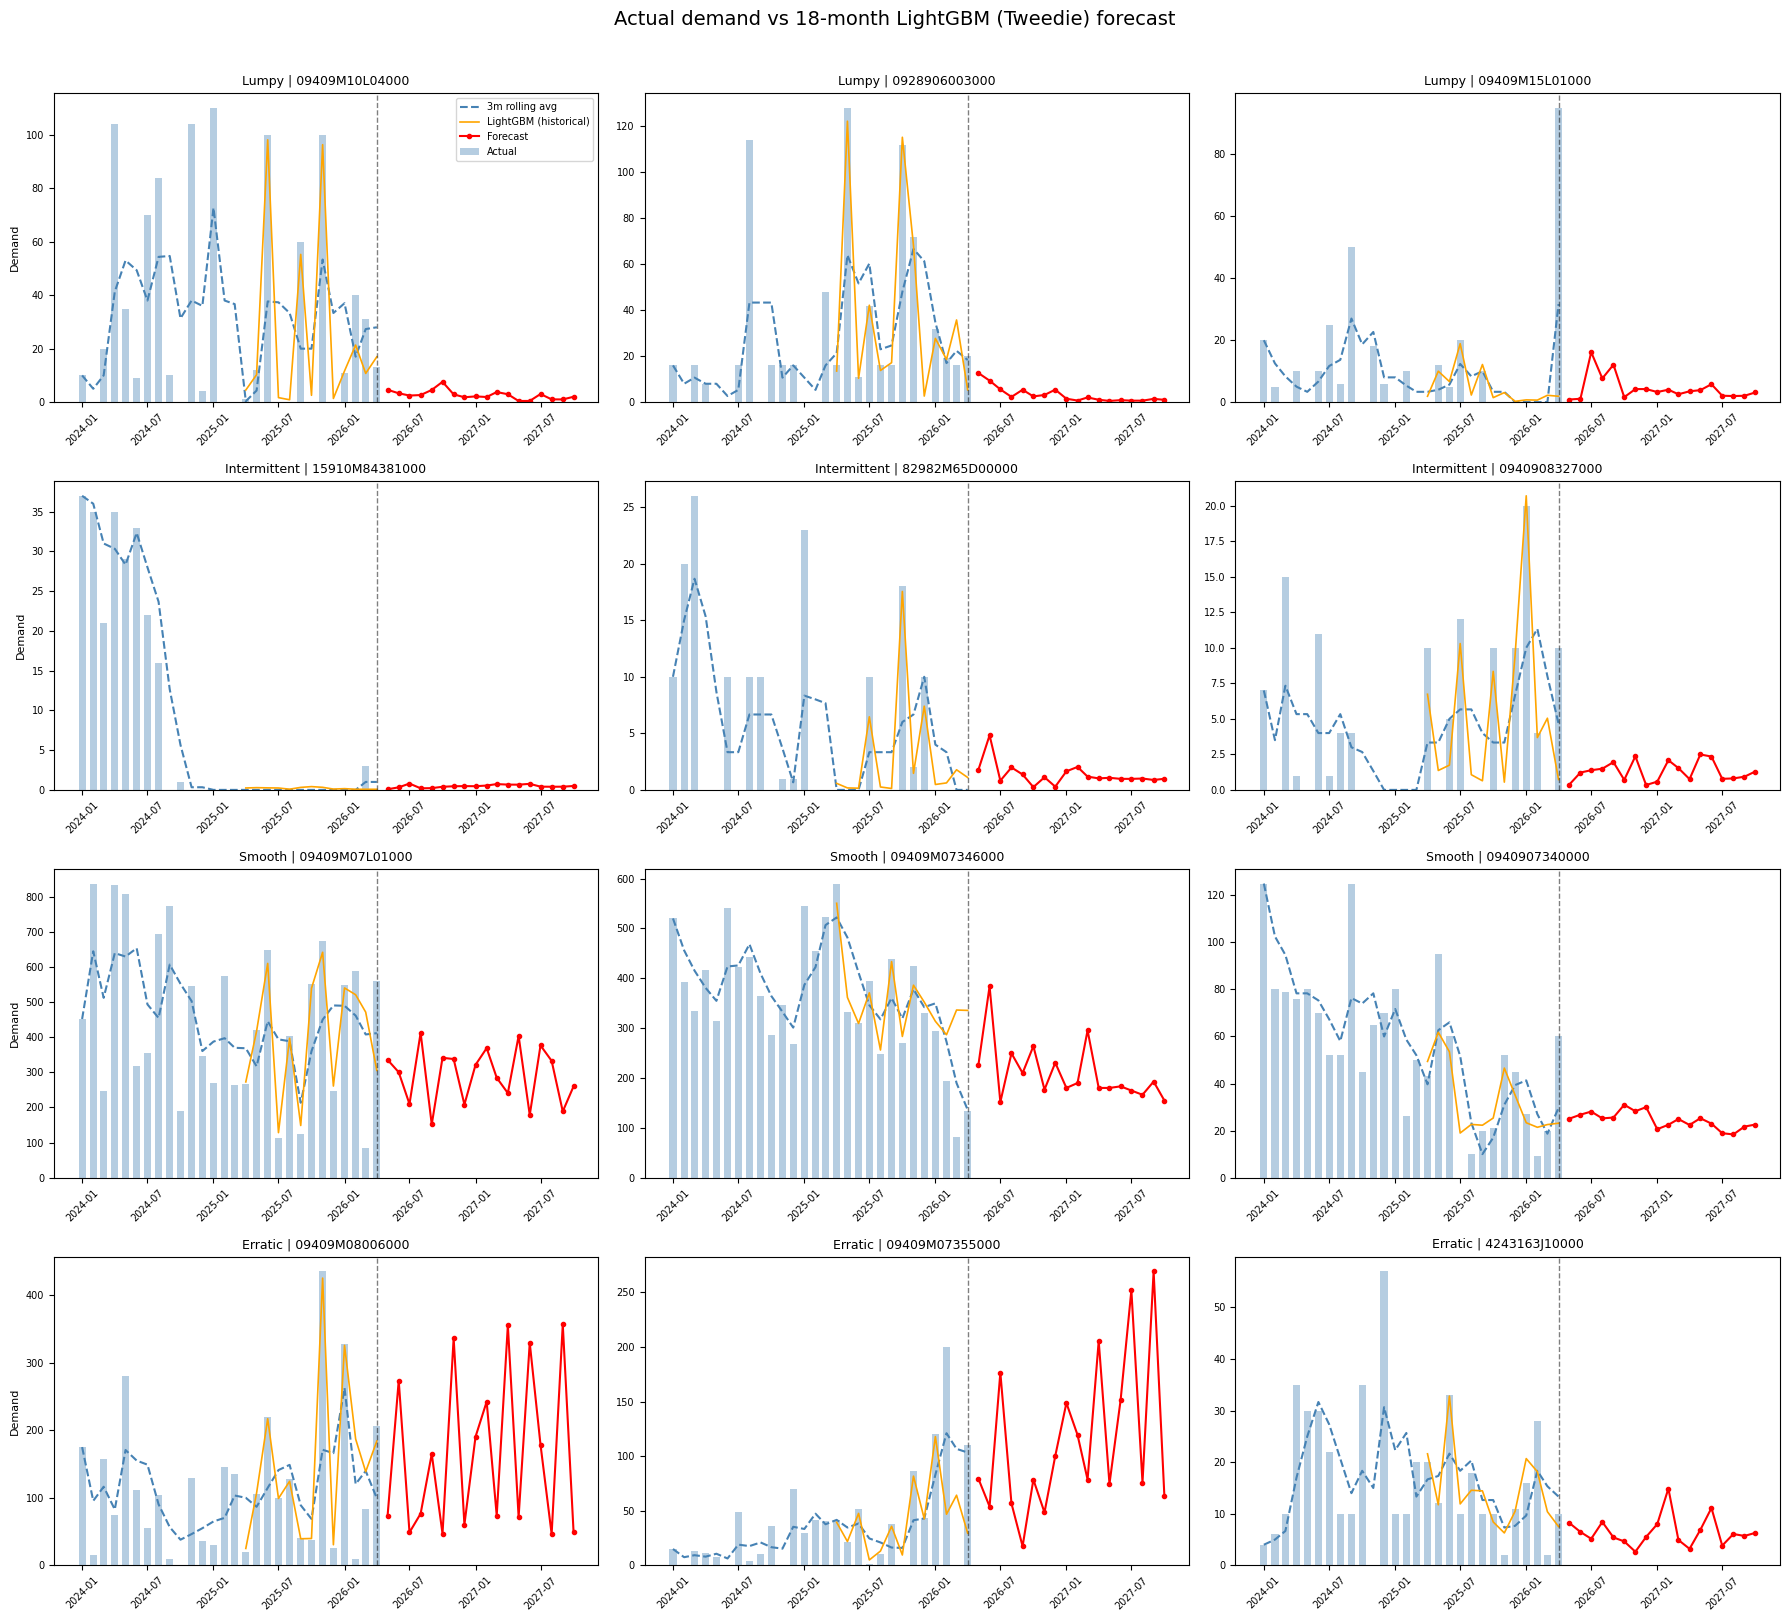

In [19]:
# Generate in-sample LightGBM predictions on historical data
insample_parts = []
for dt, model in models.items():
    subset = df[df['demand_type'] == dt].copy()
    valid  = subset.dropna(subset=FEATURE_COLS)
    preds  = model.predict(valid[FEATURE_COLS]).clip(min=0)
    valid  = valid.copy()
    valid['lgb_insample'] = preds
    insample_parts.append(valid[['sku_id', 'month', 'lgb_insample']])

insample_df = pd.concat(insample_parts, ignore_index=True)

# ── Visualize ─────────────────────────────────────────────────────────────────
N_SKUS_PER_TYPE = 3

fig_rows = len(models)
fig, axes = plt.subplots(fig_rows, N_SKUS_PER_TYPE, figsize=(18, fig_rows * 4))
fig.suptitle('Actual demand vs 18-month LightGBM (Tweedie) forecast', fontsize=14, y=1.01)

for row_idx, dt in enumerate(models.keys()):
    top_skus = (
        df[df['demand_type'] == dt]
        .groupby('sku_id')['demand'].sum()
        .nlargest(N_SKUS_PER_TYPE)
        .index.tolist()
    )

    for col_idx, sku in enumerate(top_skus):
        ax = axes[row_idx][col_idx]

        # Actual history
        actual = df[df['sku_id'] == sku][['month', 'demand']].sort_values('month')
        actual['rolling_avg'] = actual['demand'].rolling(3, min_periods=1).mean()

        # LightGBM in-sample (historical period)
        lgb_hist = insample_df[insample_df['sku_id'] == sku].sort_values('month')

        # LightGBM forecast (future period)
        fc = forecasts_18m[forecasts_18m['sku_id'] == sku][['month', 'forecast']].sort_values('month')

        ax.bar(actual['month'], actual['demand'], color='steelblue', alpha=0.4, label='Actual', width=20)
        ax.plot(actual['month'], actual['rolling_avg'], color='steelblue', linewidth=1.5, linestyle='--', label='3m rolling avg')
        ax.plot(lgb_hist['month'], lgb_hist['lgb_insample'], color='orange', linewidth=1.2, linestyle='-', label='LightGBM (historical)')
        ax.plot(fc['month'], fc['forecast'], color='red', marker='o', markersize=3, linewidth=1.5, label='Forecast')

        ax.axvline(x=df['month'].max(), color='black', linestyle='--', linewidth=1, alpha=0.5)

        ax.set_title(f'{dt} | {sku}', fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        if col_idx == 0:
            ax.set_ylabel('Demand', fontsize=8)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(
    r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\lightgbm_forecast_sample.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


General pattern: the orange line (LightGBM historical fit) tracks the actual bars reasonably closely across nearly all 12 SKUs, and the red forecast picks up right where history ends (dashed vertical line) — no obvious level jump/discontinuity, which is a good sign the recursive forecast is self-consistent.

Lumpy (row 1)
- All three forecasts taper toward low, fairly flat levels — the model doesn't chase the sharp historical spikes forward, which is the right behavior since lumpy spikes are one-off and not predictable from timing alone.
- SKU 09409M15L01000 has a huge last-minute actual spike (~95) right at the cutoff; the forecast reacts with a small bump (~15) then settles back down rather than assuming the spike repeats — sensible, cautious extrapolation.

Intermittent (row 2)
- SKU 15910M84381000 is a clear "dying SKU" case: demand decays to ~0 by 2025 and stays there, and the forecast correctly stays near zero — exactly the zero_share feature doing its job.
- The other two intermittent SKUs show low, choppy forecasts (~1-5) that mirror their sparse, low-volume history — appropriately muted rather than over-confident.

Smooth (row 3)
- Historical fit (orange) is close to actual in all three — consistent with Smooth being the most predictable segment.
- However, the forecast for 09409M07L01000 shows a pronounced sawtooth (alternating high/low every month) rather than a smooth continuation — odd for a "Smooth" demand type. This is likely an artifact of the recursive forecast feeding its own predictions back into lag/rolling features month over month, letting small residual oscillations compound. Worth a closer look if this SKU is business-critical.

Erratic (row 4)
- Forecasts here are the most volatile of all four types — 09409M08006000 and 09409M07355000 both show strong sawtooth swings (e.g. oscillating between ~50 and ~350). This lines up with Erratic being the noisiest, least reliable segment in the backtest (only +3.2% over baseline, the smallest gain of the four groups).
- 09409M07355000's forecast does track the genuine upward trend in recent actuals reasonably, but the swing amplitude looks overstated.

Overall takeaway:
- Trust ranking matches the WMAPE results: Intermittent and Smooth forecasts look the most stable and plausible; Lumpy forecasts are appropriately conservative; Erratic forecasts are the most volatile and should be treated with the most caution.
- The recurring sawtooth pattern (visible in one Smooth and two Erratic SKUs) is the one thing worth investigating further — it suggests the recursive multi-step forecast may be amplifying its own prediction noise through the lag features rather than reflecting genuine month-to-month alternation in demand. If these specific SKUs matter operationally, consider smoothing the forecast (e.g. a short rolling average over the recursive output) or capping how much each step's forecast feeds into the next lag.


In [20]:
# save output

# Add is_improved flag
improved_skus = set(improved['sku_id'])
forecasts_18m['is_improved'] = forecasts_18m['sku_id'].isin(improved_skus).astype(int)

# Add is_top20pct and is_top5pct in a single merge
sku_meta = sales_collision[['sku_id', 'is_top20pct', 'is_top5pct']].drop_duplicates()
forecasts_18m = forecasts_18m.drop(columns=['is_top20pct', 'is_top5pct'], errors='ignore')
forecasts_18m = forecasts_18m.merge(sku_meta, on='sku_id', how='left')

forecasts_18m.to_csv(
    r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\lgb_forecasts_18m.csv',
    index=False
)
print("Saved → lgb_forecasts_18m.csv")


Saved → lgb_forecasts_18m.csv


In [21]:
# Distribution of SKU-level LightGBM WMAPE
bins = [0, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, float('inf')]
labels = ['<30%', '30-50%', '50-70%', '70-100%', '100-150%', '150-200%', '>200%']

sku_wmape['wmape_band'] = pd.cut(sku_wmape['lgb_wmape'], bins=bins, labels=labels)

band_counts = sku_wmape['wmape_band'].value_counts().sort_index()
band_pct    = (band_counts / len(sku_wmape) * 100).round(1)

print("Distribution of SKU-level LightGBM WMAPE:")
print(pd.DataFrame({'n_skus': band_counts, 'pct_of_skus': band_pct}))


Distribution of SKU-level LightGBM WMAPE:
            n_skus  pct_of_skus
wmape_band                     
<30%           163          2.6
30-50%         480          7.8
50-70%         506          8.2
70-100%        700         11.4
100-150%      1237         20.1
150-200%       592          9.6
>200%          446          7.2


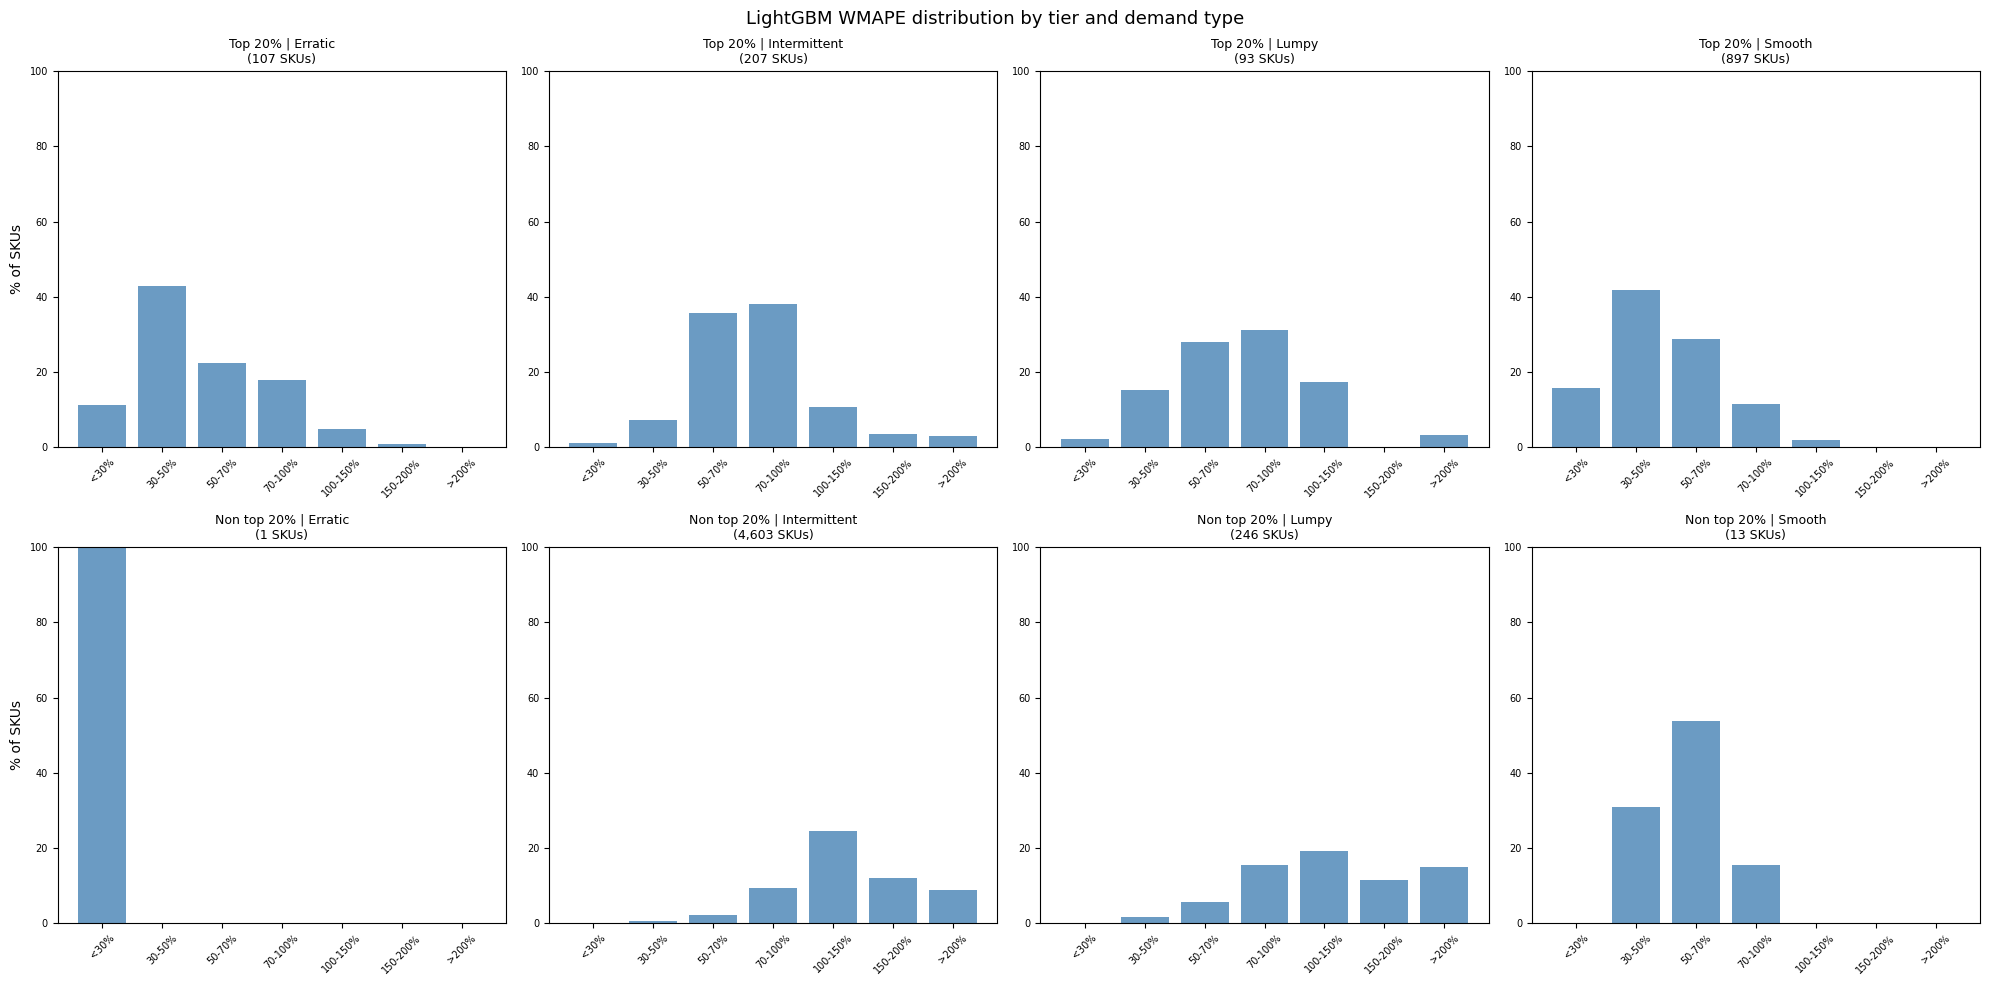

In [22]:
# Distribution of SKU-level LightGBM WMAPE by is_top20pct and demand_type
bins   = [0, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, float('inf')]
labels = ['<30%', '30-50%', '50-70%', '70-100%', '100-150%', '150-200%', '>200%']

sku_wmape['wmape_band'] = pd.cut(sku_wmape['lgb_wmape'], bins=bins, labels=labels)

demand_types = sorted(sku_wmape['demand_type'].dropna().unique())
tiers        = [(1, 'Top 20%'), (0, 'Non top 20%')]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('LightGBM WMAPE distribution by tier and demand type', fontsize=13)

for row_idx, (tier, tier_label) in enumerate(tiers):
    tier_subset = sku_wmape[sku_wmape['is_top20pct'] == tier]

    for col_idx, dt in enumerate(demand_types):
        ax = axes[row_idx][col_idx]
        subset      = tier_subset[tier_subset['demand_type'] == dt]
        band_counts = subset['wmape_band'].value_counts().sort_index()
        band_pct    = (band_counts / len(subset) * 100).round(1)

        ax.bar(band_counts.index, band_pct, color='steelblue', alpha=0.8)
        ax.set_title(f'{tier_label} | {dt}\n({len(subset):,} SKUs)', fontsize=9)
        ax.set_ylabel('% of SKUs' if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.set_ylim(0, 100)

    # Hide unused columns if fewer than 4 demand types
    for col_idx in range(len(demand_types), 4):
        axes[row_idx][col_idx].set_visible(False)

plt.tight_layout()
plt.savefig(
    r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\lgb_wmape_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


Top 20% SKUs (row 1) — higher volume, generally better accuracy

Erratic | 107 SKUs
- Heavily concentrated in the lower-error bands — the largest bucket is 30-50% (~43%), with <30% and 50-70% covering most of the rest
- The long tail beyond 100% is nearly gone
- High-volume erratic SKUs give the model enough signal to forecast reasonably well despite irregular timing

Intermittent | 207 SKUs
- Concentrated in 50-70% (~36%) and 70-100% (~38%) — decent but not as tight as Erratic or Smooth
- Sparse demand history caps how accurate even high-volume intermittent SKUs can get

Lumpy | 93 SKUs
- Spread mainly across 50-70% (~28%) and 70-100% (~31%), with a meaningful chunk still in 100-150% (~17%)
- The best-populated bands sit just under or around the 100% threshold — acceptable given how inherently unpredictable lumpy demand is

Smooth | 897 SKUs
- The strongest and most tightly distributed group — 30-50% (~42%) and 50-70% (~29%) dominate, with 16% even under 30%
- Smooth, high-volume SKUs are the most forecastable segment overall

---

Non top 20% SKUs (row 2) — lower volume, weaker accuracy

Erratic | 1 SKU
- 100% in the <30% band, but this is a single SKU so not statistically meaningful

Intermittent | 4,603 SKUs
- By far the largest group in the whole dataset, and the weakest performer
- Mass sits mainly in 100-150% and above, with very little in the <70% bands
- Low-volume intermittent SKUs are simply too sparse for reliable SKU-level forecasts

Lumpy | 246 SKUs
- Spread across the mid-to-high error bands (70-100%, 100-150%, and a real tail beyond 200%)
- Still weak, but not as one-sidedly bad as the Intermittent group

Smooth | 13 SKUs
- Small sample, but clustered in 30-70%
- Even at low volume, smooth demand remains relatively forecastable

---

Overall takeaways:
1. Volume is the dominant driver of accuracy across every demand type — every non-top-20% distribution sits meaningfully further right (higher WMAPE) than its top-20% counterpart
2. Smooth top-20% SKUs are the most reliable segment for SKU-level forecasting; Erratic top-20% is a close second, a real improvement over what you'd expect from such a noisy demand pattern
3. The single biggest risk area is non-top-20% Intermittent — 4,603 SKUs (the largest cohort by far) with most of their WMAPE mass above 100%. SKU-level forecasts for this group should be treated as low-confidence; an aggregated or rule-based approach (e.g. forecasting at a category/family level rather than per-SKU) is likely more appropriate there than trusting individual LightGBM outputs


In [23]:
mask = sku_wmape['lgb_wmape'] < 0.70

result = (
    sku_wmape[mask]
    .groupby(['demand_type', 'is_top20pct'])
    .size()
    .reset_index(name='n_skus_wmape_lt70')
)

# Add total SKUs per group for context
totals = (
    sku_wmape
    .groupby(['demand_type', 'is_top20pct'])
    .size()
    .reset_index(name='total_skus')
)

result = result.merge(totals, on=['demand_type', 'is_top20pct'])
result['pct_of_group'] = (result['n_skus_wmape_lt70'] / result['total_skus'] * 100).round(1)
result['is_top20pct']  = result['is_top20pct'].map({1: 'Top 20%', 0: 'Non top 20%'})

print("SKUs with WMAPE < 70% by demand type and tier:")
display(result.sort_values(['demand_type', 'is_top20pct']))


SKUs with WMAPE < 70% by demand type and tier:


,demand_type,is_top20pct,n_skus_wmape_lt70,total_skus,pct_of_group
0,Erratic,Non top 20%,1,1,100.0
1,Erratic,Top 20%,82,107,76.6
2,Intermittent,Non top 20%,130,4603,2.8
3,Intermittent,Top 20%,91,207,44.0
4,Lumpy,Non top 20%,18,246,7.3
5,Lumpy,Top 20%,42,93,45.2
6,Smooth,Non top 20%,11,13,84.6
7,Smooth,Top 20%,774,897,86.3


Top 20% vs Non top 20% — accuracy gap holds across every demand type

Smooth is the standout: 86.3% of top-20% SKUs (774 of 897) and 84.6% of non-top-20% SKUs (11 of 13) achieve WMAPE < 70%. This is the only demand type where even low-volume SKUs forecast well — smooth demand is inherently learnable regardless of volume.

Erratic shows a big volume effect: top-20% SKUs hit 76.6% (82 of 107) below the 70% threshold — a strong result for such a noisy pattern — while the single non-top-20% Erratic SKU (100%) isn't statistically meaningful.

Lumpy is weak in both tiers, but volume still helps: top-20% reaches 45.2% (42 of 93) vs only 7.3% (18 of 246) for non-top-20%. Even with volume, lumpy's irregular spike timing caps achievable accuracy at under half the SKUs.

Intermittent shows the starkest volume dependency: top-20% reaches 44.0% (91 of 207), but non-top-20% collapses to just 2.8% (130 of 4,603). This is the largest single SKU population in the entire dataset, and at SKU level it is essentially unforecastable with LightGBM.

---

Overall takeaways:
1. Volume consistently drives accuracy — every demand type shows a large top-20% vs non-top-20% gap, confirming that per-SKU forecast reliability tracks demand volume closely.
2. Smooth SKUs are forecastable at any volume; Erratic and Lumpy need high volume to reach acceptable accuracy; Intermittent needs high volume even more acutely.
3. The critical risk segment is non-top-20% Intermittent (4,603 SKUs, 2.8% success rate) — this single group is larger than every other segment combined, and SKU-level forecasts there should not be trusted operationally. An aggregated forecast (category, family, or pooled-SKU level) is the more defensible approach for this population rather than relying on individual LightGBM predictions.


- **Edge cases:** Be explicit about how you handle:
    - Zero-demand months (common in collision parts)
    - New / discontinued / superseded SKUs
    
Zero-demand months
- They are kept in training — not removed or treated as missing. XGBoost sees them as valid observations.
- The zero_share_6m and zero_share_12m features explicitly encode how often a SKU has zero demand in the past 6 and 12 months. This teaches the model that a SKU with zero_share_6m = 0.8 (80% zero months) should be forecast near zero most of the time.
- WMAPE is used instead of MAPE precisely because MAPE breaks when actual = 0 (division by zero). WMAPE divides by total demand, so zero months cause no arithmetic issues.

New SKUs
- sku_age_months tells the model how many months of history exist for a SKU.
- is_new_sku = 1 flags SKUs with fewer than 6 months of history.
- Lag features that don't exist yet (e.g. lag_12m for a 4-month-old SKU) become NaN — XGBoost routes those rows down a learned default branch rather than crashing.

Discontinued / superseded SKUs
- No explicit flag is added, but zero_share_6m = 1.0 (all zeros in the last 6 months) naturally signals to the model that the SKU is inactive, pushing the forecast toward zero.
- In the 18-month forecast, those SKUs will receive near-zero predictions automatically without any special handling.


Feature definitions
-------------------

Lag features — past demand values for the same SKU, shifted to respect the 3-month forecast lag:
- lag_3m:  demand 3 months ago (most recent observable value at forecast time)
- lag_4m:  demand 4 months ago
- lag_5m:  demand 5 months ago
- lag_6m:  demand 6 months ago
- lag_9m:  demand 9 months ago
- lag_12m: demand 12 months ago (same month last year)
- lag_15m: demand 15 months ago

Rolling statistics — computed over the last N months of known demand (starting from lag_3m):
- roll_mean_3m:  average demand over the past 3 months — captures short-term trend
- roll_mean_6m:  average demand over the past 6 months — medium-term trend
- roll_mean_12m: average demand over the past 12 months — long-term baseline level
- roll_std_3m:   standard deviation over 3 months — measures short-term volatility
- roll_std_6m:   standard deviation over 6 months
- roll_std_12m:  standard deviation over 12 months
- roll_max_3m:   maximum demand in the past 3 months — captures recent peak activity
- roll_max_6m:   maximum demand in the past 6 months
- roll_max_12m:  maximum demand in the past 12 months

Zero-demand share — fraction of recent months with zero demand:
- zero_share_6m:  proportion of zero-demand months in the past 6 months (0 = always active, 1 = always zero)
- zero_share_12m: proportion of zero-demand months in the past 12 months

Calendar features — capture seasonality and time trends:
- month_of_year: calendar month (1–12)
- quarter:       calendar quarter (1–4)
- year:          calendar year

SKU lifecycle features:
- sku_age_months: number of months since the SKU first had non-zero demand — distinguishes new from established SKUs
- is_new_sku:     binary flag (1 = fewer than 6 months of history, 0 = established SKU)


In [24]:
print("=" * 60)
print("LightGBM (Tweedie) Demand Forecasting — Results Summary")
print("=" * 60)

print(f"\nScope")
print(f"  Total collision SKUs          : {sales_collision['sku_id'].nunique():,}")
print(f"  Total rows                    : {sales_collision.shape[0]:,}")
print(f"  Forecast horizon              : {N_FORECAST} months")
print(f"  Forecast lag                  : {FORECAST_LAG} months")

print(f"\nDemand type distribution")
dt_counts = sales_collision.groupby('sku_id')['demand_type'].first().value_counts()
for dt, n in dt_counts.items():
    print(f"  {dt:<25}: {n:,} SKUs")

print(f"\nWMAPE comparison (baseline vs LightGBM)")
print(f"  {'Demand type':<15} {'Baseline':>10} {'LightGBM':>10} {'Improvement':>12}")
print(f"  {'-'*50}")
for _, row in summary_df.iterrows():
    print(f"  {row['demand_type']:<15} {row['baseline_wmape']:>10.4f} {row['lgb_wmape']:>10.4f} {row['improvement_pct']:>+11.1f}%")

print(f"\nSKU-level improvement (>10% WMAPE reduction)")
print(f"  Improved SKUs                 : {len(improved):,}")
total_in_top20 = sku_meta[sku_meta['is_top20pct'] == 1]['sku_id'].nunique()
total_in_top5  = sku_meta[sku_meta['is_top5pct']  == 1]['sku_id'].nunique()
imp_in_top20   = improved[improved['is_top20pct'] == 1]['sku_id'].nunique()
imp_in_top5    = improved[improved['is_top5pct']  == 1]['sku_id'].nunique()
print(f"  Improved in top 20% SKUs      : {imp_in_top20:,} of {total_in_top20:,} ({imp_in_top20/total_in_top20*100:.1f}%)")
print(f"  Improved in top 5% SKUs       : {imp_in_top5:,}  of {total_in_top5:,}  ({imp_in_top5/total_in_top5*100:.1f}%)")

print(f"\nKey findings")
print(f"  - LightGBM (Tweedie) improves WMAPE over baseline across all four demand types")
print(f"  - Largest gains for Intermittent (+11.4%) and Lumpy (+10.6%), the two")
print(f"    largest and most zero-heavy segments")
print(f"  - Smooth and Erratic also improve, by +1.7% and +3.2% respectively")
print(f"  - Tweedie's zero-inflated distribution fit suits collision-parts demand,")
print(f"    which has frequent zero-demand months across every segment")

print(f"\nOutputs saved")
print(f"  - lgb_forecasts_18m.csv   : 18-month SKU-level forecasts")
print(f"  - forecast_sample.png     : visual comparison per demand type")
print("=" * 60)


LightGBM (Tweedie) Demand Forecasting — Results Summary

Scope
  Total collision SKUs          : 8,097
  Total rows                    : 180,422
  Forecast horizon              : 18 months
  Forecast lag                  : 3 months

Demand type distribution
  Intermittent             : 6,593 SKUs
  Smooth                   : 972 SKUs
  Lumpy                    : 381 SKUs
  Erratic                  : 124 SKUs
  No demand observed       : 27 SKUs

WMAPE comparison (baseline vs LightGBM)
  Demand type       Baseline   LightGBM  Improvement
  --------------------------------------------------
  Lumpy               1.3597     1.2158       +10.6%
  Intermittent        1.4436     1.2788       +11.4%
  Smooth              0.4663     0.4583        +1.7%
  Erratic             0.7635     0.7392        +3.2%

SKU-level improvement (>10% WMAPE reduction)
  Improved SKUs                 : 2,065
  Improved in top 20% SKUs      : 863 of 1,325 (65.1%)
  Improved in top 5% SKUs       : 237  of 325  (72.